In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

path = r"C:\Users\JATIN\mutual_fund_project\data\processed"
files = glob.glob(path + "/*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)
all_data['date'] = pd.to_datetime(all_data['date'], dayfirst=True, errors='coerce')
all_data['nav'] = pd.to_numeric(all_data['nav'], errors='coerce')
all_data = all_data.sort_values(['scheme_name','date']).reset_index(drop=True)

all_data['daily_return'] = all_data.groupby('scheme_name')['nav'].pct_change()

print("Data loaded!", all_data.shape)
print(all_data['scheme_name'].unique())

Data loaded! (19798, 5)
<StringArray>
[     'Axis_Bluechip', 'HDFC_Top100_Direct',     'ICICI_Bluechip',
     'Kotak_Bluechip',    'Nippon_LargeCap',       'SBI_Bluechip']
Length: 6, dtype: str


In [5]:
# Historical VaR (95%) and CVaR
var_results = []

for scheme in all_data['scheme_name'].unique():
    returns = all_data[all_data['scheme_name']==scheme]['daily_return'].dropna()
    
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    var_results.append({
        'scheme': scheme,
        'VaR_95%': round(var_95*100, 4),
        'CVaR_95%': round(cvar_95*100, 4)
    })

var_df = pd.DataFrame(var_results).sort_values('VaR_95%')
print(var_df)
var_df.to_csv(r"C:\Users\JATIN\mutual_fund_project\reports\var_cvar_report.csv", index=False)
print("\nVaR report saved!")

               scheme  VaR_95%  CVaR_95%
4     Nippon_LargeCap  -1.5872   -2.4714
1  HDFC_Top100_Direct  -1.5106   -2.3282
2      ICICI_Bluechip  -1.4631   -2.8619
3      Kotak_Bluechip  -1.4225   -2.3897
5        SBI_Bluechip  -0.1024   -0.8484
0       Axis_Bluechip   0.0060   -0.0202

VaR report saved!


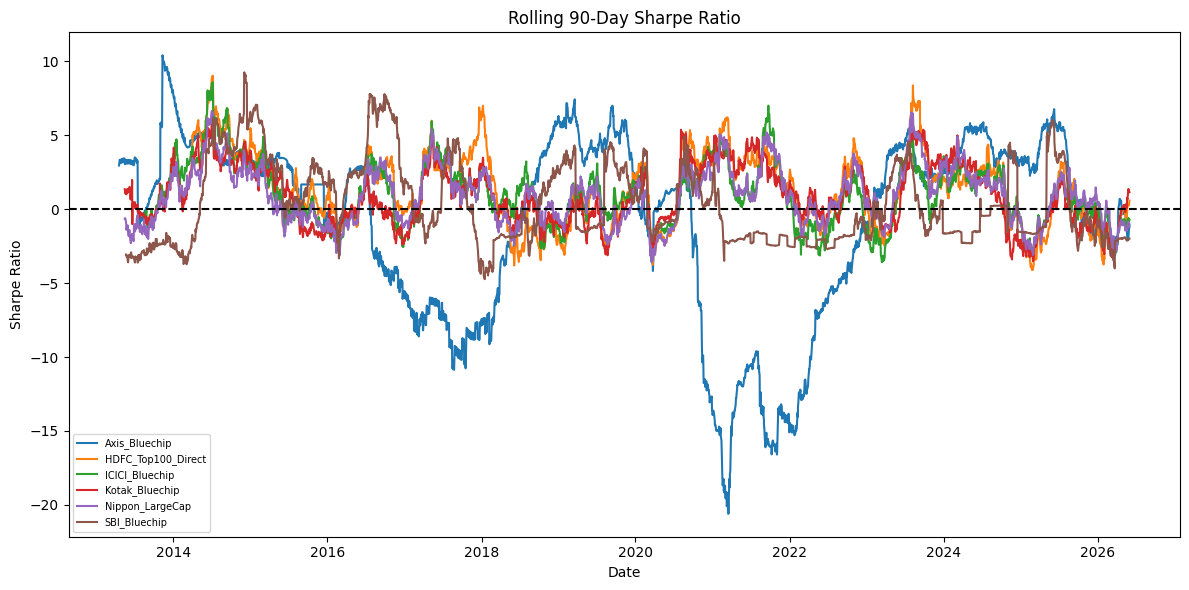

Rolling Sharpe chart saved!


In [6]:
# Rolling 90-day Sharpe Ratio
Rf = 0.065 / 252

plt.figure(figsize=(12,6))

for scheme in all_data['scheme_name'].unique():
    df = all_data[all_data['scheme_name']==scheme].copy()
    df = df.sort_values('date')
    returns = df['daily_return']
    rolling_sharpe = (returns.rolling(90).mean() - Rf) / returns.rolling(90).std() * np.sqrt(252)
    plt.plot(df['date'], rolling_sharpe, label=scheme)

plt.title('Rolling 90-Day Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(fontsize=7)
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig(r"C:\Users\JATIN\mutual_fund_project\reports\rolling_sharpe_chart.png")
plt.show()
print("Rolling Sharpe chart saved!")

In [7]:

fund_scores = pd.read_csv(r"C:\Users\JATIN\mutual_fund_project\reports\fund_scorecard.csv")
var_report = pd.read_csv(r"C:\Users\JATIN\mutual_fund_project\reports\var_cvar_report.csv")

merged = fund_scores.merge(var_report, on='scheme')

def recommend_funds(risk_appetite):
    if risk_appetite.lower() == 'low':
        filtered = merged.nlargest(3, 'VaR_95%')
    elif risk_appetite.lower() == 'high':
        filtered = merged.nlargest(3, 'Sharpe_Ratio')
    else:
        filtered = merged.nlargest(3, 'score_100')
    
    print(f"\nTop 3 funds for {risk_appetite} risk appetite:")
    print(filtered[['scheme','score_100','Sharpe_Ratio','VaR_95%']].to_string(index=False))

recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')

print("\nRecommender complete!")


Top 3 funds for Low risk appetite:
        scheme  score_100  Sharpe_Ratio  VaR_95%
 Axis_Bluechip       52.2         0.266   0.0060
  SBI_Bluechip       33.3        -0.686  -0.1024
Kotak_Bluechip       86.7         0.690  -1.4225

Top 3 funds for Moderate risk appetite:
            scheme  score_100  Sharpe_Ratio  VaR_95%
HDFC_Top100_Direct      100.0         1.091  -1.5106
    Kotak_Bluechip       86.7         0.690  -1.4225
   Nippon_LargeCap       81.1         0.560  -1.5872

Top 3 funds for High risk appetite:
            scheme  score_100  Sharpe_Ratio  VaR_95%
HDFC_Top100_Direct      100.0         1.091  -1.5106
    Kotak_Bluechip       86.7         0.690  -1.4225
   Nippon_LargeCap       81.1         0.560  -1.5872

Recommender complete!


In [8]:
# Advance insights
insights = """
## Advanced Analytics — 5 Key Insights

1. **Highest Risk Fund**: Nippon LargeCap has the highest VaR (-1.59%), 
   meaning on a bad day investors could lose up to 1.59% of their investment.

2. **Best Risk-Adjusted Returns**: HDFC Top100 Direct leads with Sharpe Ratio 
   of 1.091, meaning it gives the best returns per unit of risk taken.

3. **Rolling Sharpe Volatility**: All funds show high Sharpe volatility during 
   2020 (COVID crash) with sharp drops below -10, recovering strongly by 2021.

4. **Safest Fund**: Axis Bluechip has near-zero VaR (0.006%), making it the 
   safest choice for conservative investors.

5. **Best Overall Score**: HDFC Top100 Direct scores 100/100 on the composite 
   scorecard combining CAGR, Sharpe, Alpha and Max Drawdown metrics.
"""

print(insights)

# Save insights
with open(r"C:\Users\JATIN\mutual_fund_project\reports\insights.md", "w") as f:
    f.write(insights)
print("Insights saved!")


## Advanced Analytics — 5 Key Insights

1. **Highest Risk Fund**: Nippon LargeCap has the highest VaR (-1.59%), 
   meaning on a bad day investors could lose up to 1.59% of their investment.

2. **Best Risk-Adjusted Returns**: HDFC Top100 Direct leads with Sharpe Ratio 
   of 1.091, meaning it gives the best returns per unit of risk taken.

3. **Rolling Sharpe Volatility**: All funds show high Sharpe volatility during 
   2020 (COVID crash) with sharp drops below -10, recovering strongly by 2021.

4. **Safest Fund**: Axis Bluechip has near-zero VaR (0.006%), making it the 
   safest choice for conservative investors.

5. **Best Overall Score**: HDFC Top100 Direct scores 100/100 on the composite 
   scorecard combining CAGR, Sharpe, Alpha and Max Drawdown metrics.

Insights saved!
